In [39]:
import pandas as pd
from scipy import stats
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [19]:
df=pd.read_csv('US_honey_dataset_updated.csv')

In [20]:
df.head(2)

,Unnamed: 0,state,colonies_number,yield_per_colony,production,stocks,average_price,value_of_production,year
0,0,Alabama,16000,58,928000,28000,62.0,575000,1995
1,1,Arizona,52000,79,4108000,986000,68.0,2793000,1995


In [23]:
z_scores = np.abs(stats.zscore(df['stocks']))

In [25]:
outliers = df[z_scores > 3]

In [31]:
df_clean = df[z_scores < 3]

In [32]:
df_clean

,Unnamed: 0,state,colonies_number,yield_per_colony,production,stocks,average_price,value_of_production,year
0,0,Alabama,16000,58,928000,28000,62.00,575000,1995
1,1,Arizona,52000,79,4108000,986000,68.00,2793000,1995
2,2,Arkansas,50000,60,3000000,900000,64.00,1920000,1995
3,3,California,420000,93,39060000,4687000,60.00,23436000,1995
4,4,Colorado,45000,60,2700000,1404000,68.00,1836000,1995
...,...,...,...,...,...,...,...,...,...
1110,1110,Virginia,6000,40,79000,79000,8.23,1975000,2021
1111,1111,Washington,96000,32,1206000,1206000,2.52,7741000,2021
1112,1112,WestVirginia,6000,43,136000,136000,4.80,1238000,2021
1113,1113,Wisconsin,42000,47,750000,750000,2.81,5547000,2021


In [34]:
Q1 = df['stocks'].quantile(0.25)
Q3 = df['stocks'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['stocks'] < lower) | (df['stocks'] > upper)]

outliers

,Unnamed: 0,state,colonies_number,yield_per_colony,production,stocks,average_price,value_of_production,year
3,3,California,420000,93,39060000,4687000,60.00,23436000,1995
17,17,Michigan,97000,92,8924000,3570000,72.00,6425000,1995
28,28,NorthDakota,220000,108,23760000,3802000,63.00,14969000,1995
34,34,SouthDakota,240000,85,20400000,4896000,65.00,13260000,1995
47,47,California,390000,70,27300000,4641000,84.00,22932000,1996
...,...,...,...,...,...,...,...,...,...
1025,1025,SouthDakota,270000,72,7582000,7582000,1.56,30326000,2019
1055,1055,Montana,110000,81,3208000,3208000,1.61,14345000,2020
1060,1060,NorthDakota,495000,78,8108000,8108000,1.59,61390000,2020
1065,1065,SouthDakota,245000,61,8668000,8668000,1.77,26453000,2020


In [36]:
df_clean = df[(df['stocks'] >= lower) & (df['stocks'] <= upper)]

In [37]:
df_clean

,Unnamed: 0,state,colonies_number,yield_per_colony,production,stocks,average_price,value_of_production,year
0,0,Alabama,16000,58,928000,28000,62.00,575000,1995
1,1,Arizona,52000,79,4108000,986000,68.00,2793000,1995
2,2,Arkansas,50000,60,3000000,900000,64.00,1920000,1995
4,4,Colorado,45000,60,2700000,1404000,68.00,1836000,1995
5,5,Florida,230000,86,19780000,1780000,63.00,12461000,1995
...,...,...,...,...,...,...,...,...,...
1110,1110,Virginia,6000,40,79000,79000,8.23,1975000,2021
1111,1111,Washington,96000,32,1206000,1206000,2.52,7741000,2021
1112,1112,WestVirginia,6000,43,136000,136000,4.80,1238000,2021
1113,1113,Wisconsin,42000,47,750000,750000,2.81,5547000,2021


In [44]:
median = np.median(df['stocks'])

mad = np.median(np.abs(df['stocks'] - median))

df['modified_z'] = 0.6745 * (df['stocks'] - median) / mad

outliers = df[np.abs(df['modified_z']) > 3.5]

outliers

,Unnamed: 0,state,colonies_number,yield_per_colony,production,stocks,average_price,value_of_production,year,modified_z
3,3,California,420000,93,39060000,4687000,60.00,23436000,1995,9.392956
17,17,Michigan,97000,92,8924000,3570000,72.00,6425000,1995,6.962581
26,26,NewYork,70000,75,5250000,2100000,66.00,3465000,1995,3.764145
28,28,NorthDakota,220000,108,23760000,3802000,63.00,14969000,1995,7.467368
31,31,Oregon,52000,52,2704000,2488000,71.00,1920000,1995,4.608358
...,...,...,...,...,...,...,...,...,...,...
1055,1055,Montana,110000,81,3208000,3208000,1.61,14345000,2020,6.174939
1060,1060,NorthDakota,495000,78,8108000,8108000,1.59,61390000,2020,16.836390
1065,1065,SouthDakota,245000,61,8668000,8668000,1.77,26453000,2020,18.054842
1100,1100,NorthDakota,515000,55,2266000,2266000,2.19,62032000,2021,4.125329


In [45]:
df_clean = df[np.abs(df['modified_z']) <= 3.5]

In [46]:
df_clean

,Unnamed: 0,state,colonies_number,yield_per_colony,production,stocks,average_price,value_of_production,year,modified_z
0,0,Alabama,16000,58,928000,28000,62.00,575000,1995,-0.744126
1,1,Arizona,52000,79,4108000,986000,68.00,2793000,1995,1.340297
2,2,Arkansas,50000,60,3000000,900000,64.00,1920000,1995,1.153177
4,4,Colorado,45000,60,2700000,1404000,68.00,1836000,1995,2.249784
5,5,Florida,230000,86,19780000,1780000,63.00,12461000,1995,3.067887
...,...,...,...,...,...,...,...,...,...,...
1110,1110,Virginia,6000,40,79000,79000,8.23,1975000,2021,-0.633160
1111,1111,Washington,96000,32,1206000,1206000,2.52,7741000,2021,1.818974
1112,1112,WestVirginia,6000,43,136000,136000,4.80,1238000,2021,-0.509139
1113,1113,Wisconsin,42000,47,750000,750000,2.81,5547000,2021,0.826806


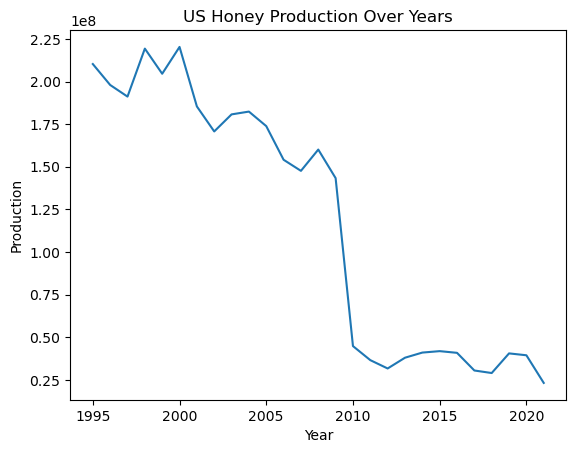

In [47]:
yearly = df.groupby('year')['production'].sum()

plt.plot(yearly.index, yearly.values)

plt.title("US Honey Production Over Years")
plt.xlabel("Year")
plt.ylabel("Production")

plt.show()

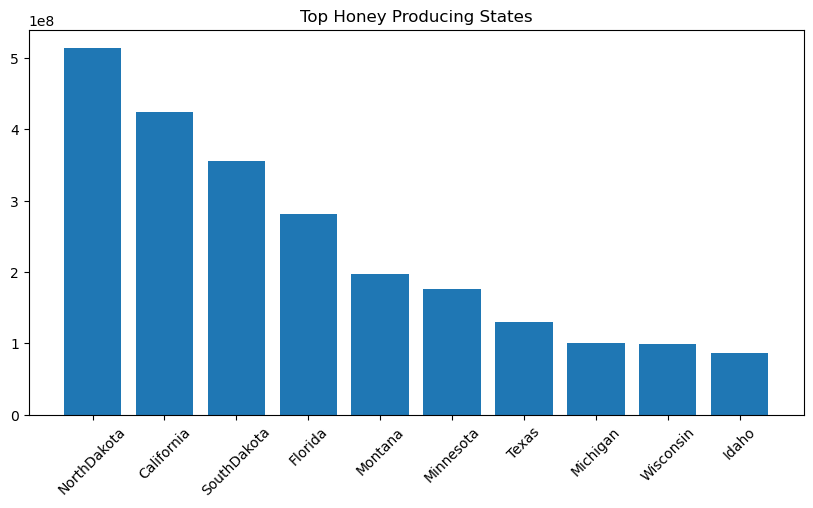

In [49]:
top_states = df.groupby('state')['production'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))

plt.bar(top_states.index, top_states.values)

plt.title("Top Honey Producing States")

plt.xticks(rotation=45)

plt.show()

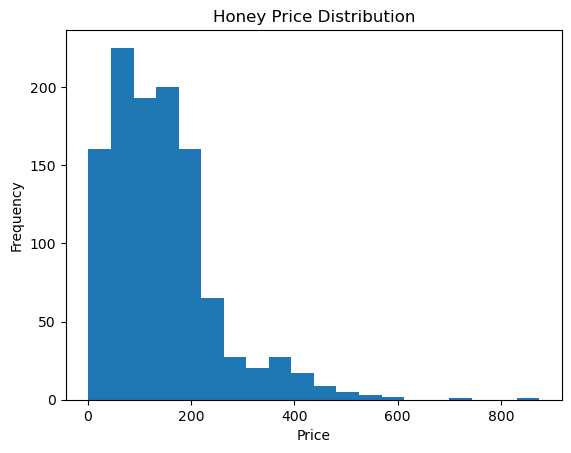

In [50]:
plt.hist(df['average_price'], bins=20)

plt.title("Honey Price Distribution")

plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

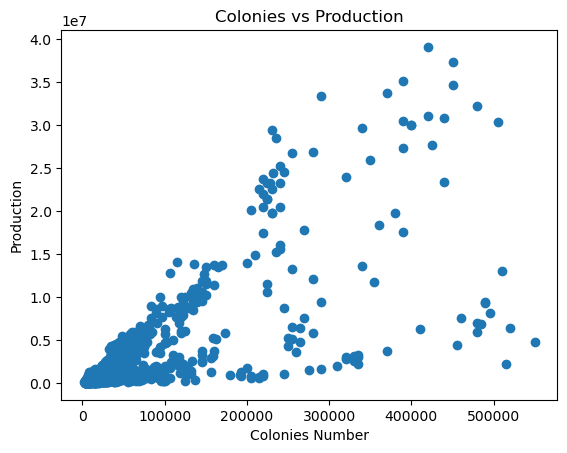

In [51]:
plt.scatter(df['colonies_number'], df['production'])

plt.title("Colonies vs Production")

plt.xlabel("Colonies Number")
plt.ylabel("Production")

plt.show()

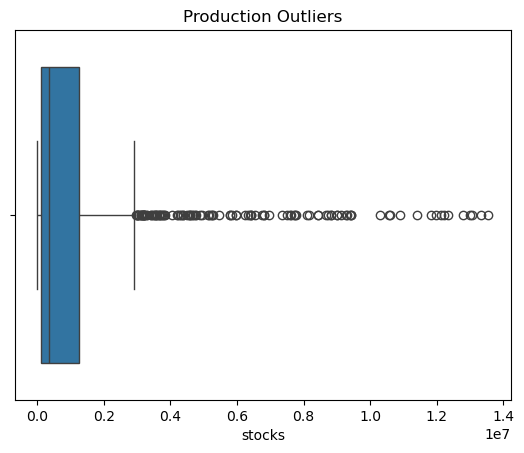

In [56]:
sns.boxplot(x=df['stocks'])

plt.title("Production Outliers")

plt.show()

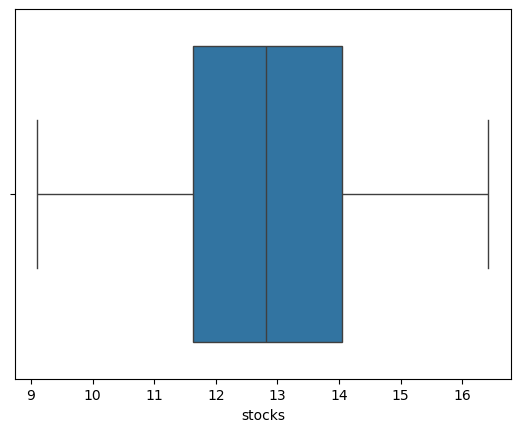

In [57]:
sns.boxplot(x=np.log(df['stocks']))
plt.show()

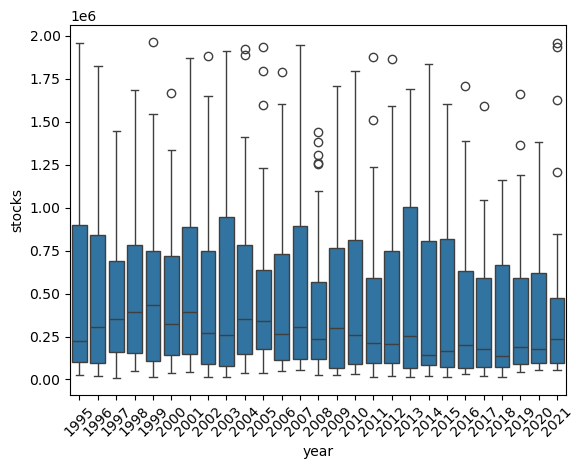

In [58]:
sns.boxplot(x='year', y='stocks', data=df_clean)
plt.xticks(rotation=45)
plt.show()

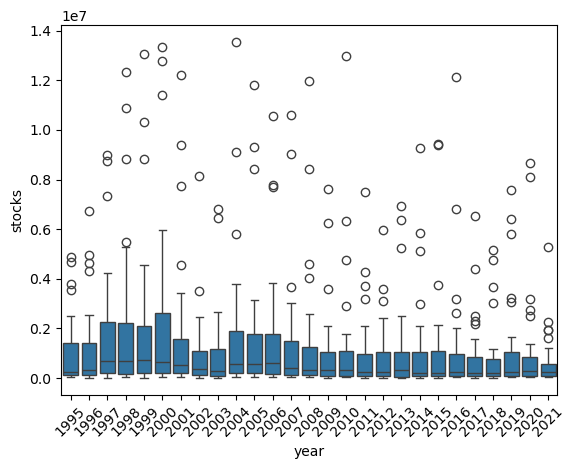

In [59]:
sns.boxplot(x='year', y='stocks', data=df)
plt.xticks(rotation=45)
plt.show()

In [60]:
df['stocks'].skew()

3.3228662395538273

In [61]:
df_clean['stocks'].skew()

1.2810125788288165